In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt

- Extra packages needed for the notebook:

! python -m pip install venn pyyaml scikit-learn

# Get max curated data

In [3]:
import requests
from yaml import safe_load
import numpy as np
import re

activities = ["Ki", "IC50"]
data_url = "https://raw.githubusercontent.com/rinikerlab/overlapping_assays/refs/heads/main/datasets/{dataset}_datasets.yaml"


command_str = (
    "capricho get -tids {targets} -chiral -duchi -reqdoc "
    "-cure --max-assay-size 100 --min-assay-size 20 -smr -calc -c 9,8,7 "
    "-biotype {activity}"  # -idcols assay_type
)

## Ki

In [4]:
result = requests.get(data_url.format(dataset=activities[0]))
result.raise_for_status()

datasets = safe_load(result.content)

ki_targets = []
keys = datasets["sources"].keys()
for key in keys:
    ki_targets.append(datasets["sources"][key]["description"])

ki_targets = np.unique(ki_targets).tolist()
ki_targets = [re.compile("(CHEMBL\d+)").search(t).group(1) for t in ki_targets]
command = command_str.format(targets=",".join(ki_targets), activity=activities[0]) + " -o curated-Ki-NoAssayOverlap.csv"
print(command)

capricho get -tids CHEMBL205,CHEMBL214,CHEMBL217,CHEMBL218,CHEMBL224,CHEMBL226,CHEMBL228,CHEMBL233,CHEMBL234,CHEMBL237,CHEMBL243,CHEMBL244,CHEMBL251,CHEMBL253,CHEMBL255,CHEMBL256,CHEMBL259,CHEMBL261,CHEMBL264,CHEMBL313,CHEMBL3155,CHEMBL3242,CHEMBL3371,CHEMBL344,CHEMBL3594,CHEMBL4153 -chiral -duchi -reqdoc -cure --max-assay-size 100 --min-assay-size 20 -smr -calc -c 9,8,7 -biotype Ki -o curated-Ki-NoAssayOverlap.csv


## IC50

In [5]:
result = requests.get(data_url.format(dataset=activities[1]))
result.raise_for_status()

datasets = safe_load(result.content)

ic50_targets = []
keys = datasets["sources"].keys()
for key in keys:
    ic50_targets.append(datasets["sources"][key]["description"])

ic50_targets = np.unique(ic50_targets).tolist()
ic50_targets = [re.compile("(CHEMBL\d+)").search(t).group(1) for t in ic50_targets]
command = command_str.format(targets=",".join(ic50_targets), activity=activities[1]) + " -o curated-IC50-NoAssayOverlap.csv"
print(command)

capricho get -tids CHEMBL1163125,CHEMBL1741186,CHEMBL1865,CHEMBL1974,CHEMBL2039,CHEMBL203,CHEMBL206,CHEMBL2148,CHEMBL220,CHEMBL222,CHEMBL228,CHEMBL2409,CHEMBL240,CHEMBL243,CHEMBL247,CHEMBL260,CHEMBL262,CHEMBL279,CHEMBL284,CHEMBL2971,CHEMBL3105,CHEMBL3130,CHEMBL3229,CHEMBL325,CHEMBL3267,CHEMBL344,CHEMBL3471,CHEMBL3717,CHEMBL4005,CHEMBL4015,CHEMBL4078,CHEMBL4235,CHEMBL4296,CHEMBL4685,CHEMBL4794,CHEMBL4822,CHEMBL5145,CHEMBL5251,CHEMBL5763 -chiral -duchi -reqdoc -cure --max-assay-size 100 --min-assay-size 20 -smr -calc -c 9,8,7 -biotype IC50 -o curated-IC50-NoAssayOverlap.csv


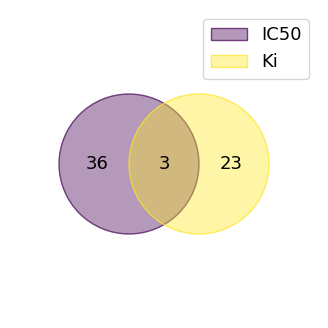

In [6]:
from venn import venn

venn_dict = {"IC50": set(ic50_targets), "Ki": set(ki_targets)}
venn(venn_dict, figsize=(4, 4))

plt.show()

# IC50 overlap

In [7]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import get_cmap
from scipy import stats  # For Spearman R and Kendall Tau
from sklearn.metrics import r2_score

In [8]:
df = pd.read_csv("curated-IC50-NoAssayOverlap.csv")
subset = df.query('processed_smiles.str.contains("|", regex=False)').assign(repeat=lambda x: range(len(x)))
subset.shape

(32267, 38)

In [9]:
# print(df.assay_type.value_counts())
# print()
processing_flags = (
    df.data_processing_comment.fillna("")
    .apply(lambda x: x.split("|"))
    .explode()
    .apply(lambda x: x.split(" & "))
    .explode()
    .unique()
    .tolist()
)

processing_flags = [p for p in processing_flags if p != ""]

dropping_flags = (
    df.data_dropping_comment.fillna("")
    .apply(lambda x: x.split("|"))
    .explode()
    .apply(lambda x: x.split(" & "))
    .explode()
    .unique()
    .tolist()
)

dropping_flags = [p for p in dropping_flags if p != ""]

all_comments = [
    "Data Validity Comment Present",
    "Potential Duplicate",
    "Undefined Stereochemistry",
    "Mutation keyword in assay description",
    "Assay size > 100",
    "Assay size < 20",
    "Unit Annotation Error",
    "Salt/solvent removed",
    "Calculated pChEMBL",
    "pChEMBL Duplication Across Documents",
]

In [10]:
def explode_assay_comparability(subset, sep_str: str = "|") -> pd.DataFrame:
    singleval_cols = [
        "connectivity",
        "target_chembl_id",
        "repeat",
    ]
    multival_cols = [
        "activity_id",
        "assay_chembl_id",
        "pchembl_value",
        "data_processing_comment",
        "data_dropping_comment",
        "standard_type",
    ]

    exploded_subset = subset[
        [
            *singleval_cols,
            *multival_cols,
        ]
    ].apply(lambda x: x.str.split(sep_str) if x.name not in singleval_cols else x)

    for col in multival_cols:
        exploded_subset[col] = exploded_subset[col].apply(
            lambda x: [sep_str.join(y) for y in combinations(x, 2)]
        )

    exploded_subset = exploded_subset.explode(multival_cols)

    suffixes = ["_x", "_y"]
    for col in multival_cols:
        values = exploded_subset[col].apply(lambda x: x.split(sep_str)).values
        for idx, s in enumerate(suffixes):
            exploded_subset[f"{col}{s}"] = [v[idx] for v in values]
        exploded_subset.drop(columns=[col], inplace=True)

    # Rename columns to make them briefer and look nicer in the plot :)
    exploded_subset = exploded_subset.assign(
        processing_comment=lambda x: x["data_processing_comment_x"].fillna("")
        + sep_str
        + x["data_processing_comment_y"].fillna(""),
        dropping_comment=lambda x: x["data_dropping_comment_x"].fillna("")
        + sep_str
        + x["data_dropping_comment_y"].fillna(""),
    ).query("assay_chembl_id_x != assay_chembl_id_y")

    exploded_subset["dropping_comment"] = (
        exploded_subset.dropping_comment.str.rstrip(sep_str)
        .str.lstrip(sep_str)
        .apply(lambda x: sep_str.join(np.unique(x.split(sep_str))))
    )
    exploded_subset["processing_comment"] = (
        exploded_subset.processing_comment.str.rstrip(sep_str)
        .str.lstrip(sep_str)
        .apply(lambda x: sep_str.join(np.unique(x.split(sep_str))))
    )
    return exploded_subset


exploded_subset = explode_assay_comparability(subset)

Text(0.5, 1.02, 'GPCR Assay Comparability Across Flagged Data')

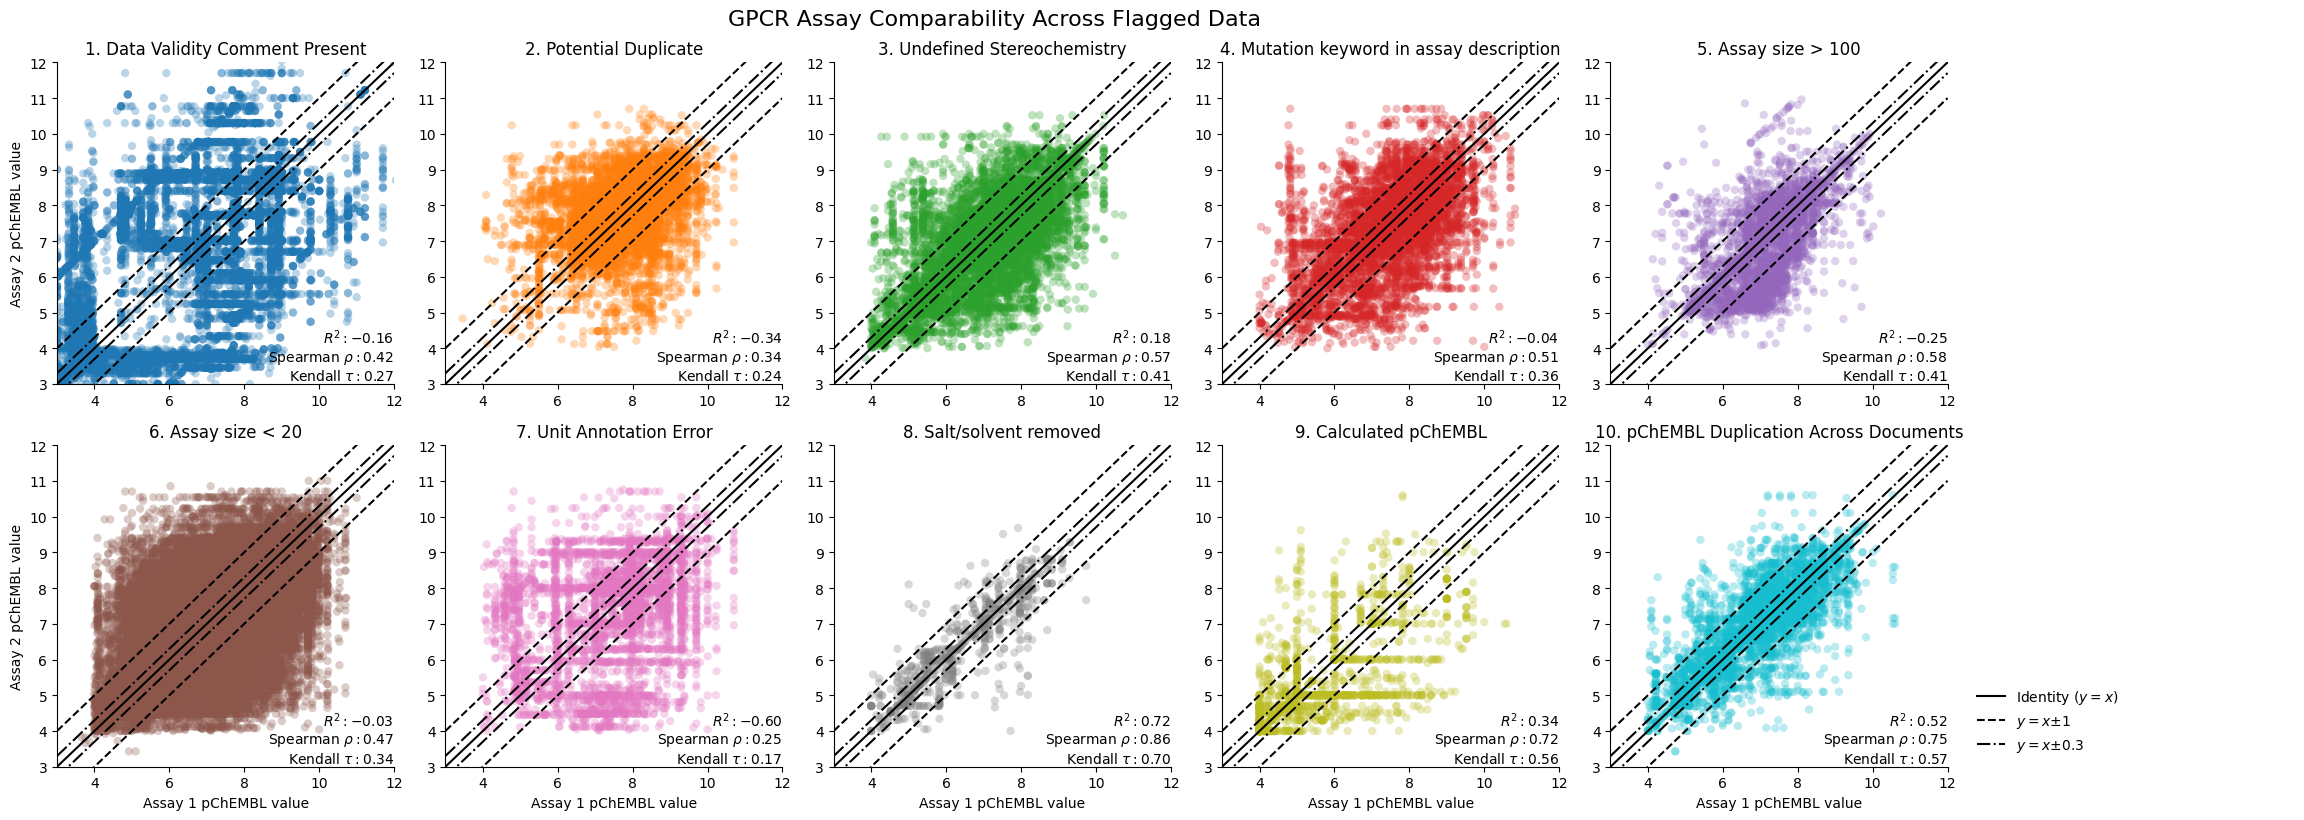

In [11]:
from matplotlib import colormaps

processing_comments = [
    "Calculated pChEMBL",
    "Salt/solvent removed",
    "pChEMBL Duplication Across Documents",
]

colors = [tuple([*col] + [1]) for col in colormaps["tab10"].colors]

fig, axs = plt.subplots(2, 5, figsize=(20, 8))

for idx, color, obs, ax in zip(range(1, 11), colors, all_comments, axs.flatten()):
    if obs == "":
        subset = exploded_subset.query(
            'dropping_comment == "" & processing_comment == ""'
        )
    else:
        if obs in processing_comments:
            subset = exploded_subset.query(
                f"processing_comment.str.contains('{obs}', regex=False)"
                "& dropping_comment == ''"
            )
        else:
            if (
                obs != "Data Validity Comment Present"
            ):  # In this case, pChEMBL is always calculated
                subset = exploded_subset.query(
                    f"dropping_comment.str.contains('{obs}', regex=False) & processing_comment == ''"
                )
            else:
                subset = exploded_subset.query(
                    f"dropping_comment.str.contains('{obs}', regex=False)"
                )
    subset.loc[:, "pchembl_value_x"] = subset.loc[:, "pchembl_value_x"].astype(float)
    subset.loc[:, "pchembl_value_y"] = subset.loc[:, "pchembl_value_y"].astype(float)
    ax.scatter(
        subset["pchembl_value_x"],
        subset["pchembl_value_y"],
        alpha=0.3,
        edgecolors="none",
        label=obs,
        color=color,
    )
    ax.set_title(f"{idx}. {obs}")
    # ax.scatter(xp, yp, alpha=0.2, edgecolors="none")
    # Add labels to each line for the legend
    ax.plot((3, 12), (3, 12), "k-", label="Identity $(y=x)$")
    ax.plot((3, 12), (2, 11), "k--")
    ax.plot((3, 12), (4, 13), "k--", label="$y=x±1$")
    ax.plot((3, 12), (2.7, 11.7), "k-.")
    ax.plot((3, 12), (3.3, 12.3), "k-.", label="$y=x±0.3$")

    # ax.title(titl)
    ax.set_xlim(3, 12)
    ax.set_ylim(3, 12)
    # remove the upper and the right spines
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    xp = subset["pchembl_value_x"]
    yp = subset["pchembl_value_y"]
    try:
        r, p = stats.spearmanr(xp, yp)
        tau, tp = stats.kendalltau(xp, yp)
        r2 = r2_score(xp, yp)
    except ValueError:
        continue

    ax.text(
        1.0,
        0.175,
        rf"$R^2: {r2:.2f}$"
        + "\n"
        + rf"Spearman $\rho: {r:.2f}$"
        + "\n"
        + rf"Kendall $\tau: {tau:.2f}$",
        transform=ax.transAxes,
        verticalalignment="top",
        horizontalalignment="right",
        # bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    if idx in [1, 6]:
        ax.set_ylabel("Assay 2 pChEMBL value")
    if idx in list(range(6, 11)):
        ax.set_xlabel("Assay 1 pChEMBL value")

    if idx == 10:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles[1:],
            labels[1:],
            title="",
            bbox_to_anchor=(1.05, 0, 1, 0.2),
            loc="lower left",
            mode="expand",
            frameon=False,
        )

fig.tight_layout()
fig.suptitle("GPCR Assay Comparability Across Flagged Data", fontsize=16, y=1.02)
# fig.savefig(
#     "IC50_qualityFilters_str_contains.png",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

/tmp/ipykernel_24881/496049917.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["pchembl_value_x"] = subset["pchembl_value_x"].astype(float)
/tmp/ipykernel_24881/496049917.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["pchembl_value_y"] = subset["pchembl_value_y"].astype(float)


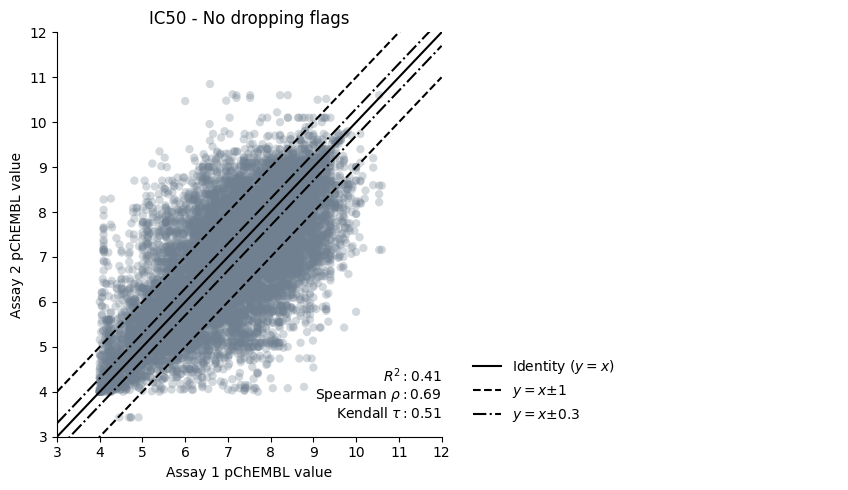

In [ ]:
from typing import Tuple
import matplotlib


def plot_subset(
    subset: pd.DataFrame, title: str = ""
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    fig, ax = plt.subplots(figsize=(5, 5))
    subset["pchembl_value_x"] = subset["pchembl_value_x"].astype(float)
    subset["pchembl_value_y"] = subset["pchembl_value_y"].astype(float)
    ax.scatter(
        subset["pchembl_value_x"],
        subset["pchembl_value_y"],
        alpha=0.3,
        edgecolors="none",
        label=obs,
        color="slategray",
    )
    ax.set_title(title)
    # ax.scatter(xp, yp, alpha=0.2, edgecolors="none")
    # Add labels to each line for the legend
    ax.plot((3, 12), (3, 12), "k-", label="Identity $(y=x)$")
    ax.plot((3, 12), (2, 11), "k--")
    ax.plot((3, 12), (4, 13), "k--", label="$y=x±1$")
    ax.plot((3, 12), (2.7, 11.7), "k-.")
    ax.plot((3, 12), (3.3, 12.3), "k-.", label="$y=x±0.3$")

    # ax.title(titl)
    ax.set_xlim(3, 12)
    ax.set_ylim(3, 12)
    # remove the upper and the right spines
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    xp = subset["pchembl_value_x"]
    yp = subset["pchembl_value_y"]

    r, p = stats.spearmanr(xp, yp)
    tau, tp = stats.kendalltau(xp, yp)
    r2 = r2_score(xp, yp)

    ax.text(
        1.0,
        0.175,
        rf"$R^2: {r2:.2f}$" + "\n" + rf"Spearman $\rho: {r:.2f}$" + "\n" + rf"Kendall $\tau: {tau:.2f}$",
        transform=ax.transAxes,
        verticalalignment="top",
        horizontalalignment="right",
        # bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    ax.set_ylabel("Assay 2 pChEMBL value")
    ax.set_xlabel("Assay 1 pChEMBL value")

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[1:],
        labels[1:],
        title="",
        bbox_to_anchor=(1.05, 0, 1, 0.2),
        loc="lower left",
        mode="expand",
        frameon=False,
    )
    fig.tight_layout()

    return fig, ax

rm_process_obs = "Calculated pChEMBL"

subset = exploded_subset.query('dropping_comment == "" & ~processing_comment.str.contains(@rm_process_obs, regex=True)')
fig, ax = plot_subset(subset, title="IC50 - No dropping flags")
fig.savefig("IC50_allFiltered.png", dpi=300, bbox_inches="tight", transparent=True)

# TODO:
- Take a look at the influence of `PAINS`
- Remove some big molecules that are in the IC50 dataset (make sure they're druglike)
- Add the same analysis for the `Ki` dataset